In [1]:
!pip install opendatasets
!pip install pandas
!pip install os

ERROR: Could not find a version that satisfies the requirement os (from versions: none)
ERROR: No matching distribution found for os


In [2]:
import os
import pandas as pd
import opendatasets as od
import zipfile
import matplotlib.pyplot as plt
from collections import defaultdict, deque
import numpy as np
import hashlib
import time

# Kaggle URL for the dataset
dataset_url = 'https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment'
 
od.download(dataset_url)

#Extract the zip file 
dataset_folder = 'twitter-airline-sentiment'

# Check zip file and extract 
for file in os.listdir(dataset_folder):
    if file.endswith('.zip'):
        with zipfile.ZipFile(os.path.join(dataset_folder, file), 'r') as zip_ref:
            zip_ref.extractall(dataset_folder)

# Step 4: Load the CSV into a pandas DataFrame
csv_path = os.path.join(dataset_folder, 'Tweets.csv')  # Update this if the CSV filename is different
df = pd.read_csv(csv_path)

# Inspect the data set
print(df.head()) 
print(df.info()) 


Skipping, found downloaded files in ".\twitter-airline-sentiment" (use force=True to force download)
             tweet_id airline_sentiment  airline_sentiment_confidence  \
0  570306133677760513           neutral                        1.0000   
1  570301130888122368          positive                        0.3486   
2  570301083672813571           neutral                        0.6837   
3  570301031407624196          negative                        1.0000   
4  570300817074462722          negative                        1.0000   

  negativereason  negativereason_confidence         airline  \
0            NaN                        NaN  Virgin America   
1            NaN                     0.0000  Virgin America   
2            NaN                        NaN  Virgin America   
3     Bad Flight                     0.7033  Virgin America   
4     Can't Tell                     1.0000  Virgin America   

  airline_sentiment_gold        name negativereason_gold  retweet_count  \
0     


Processed tweets 1 to 200


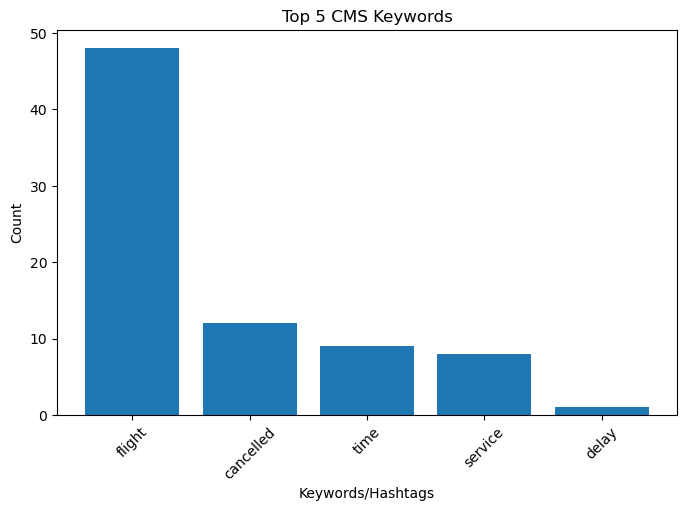

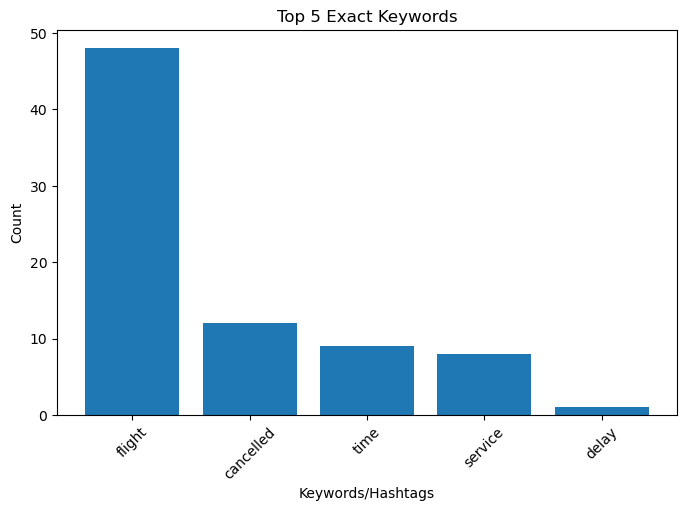

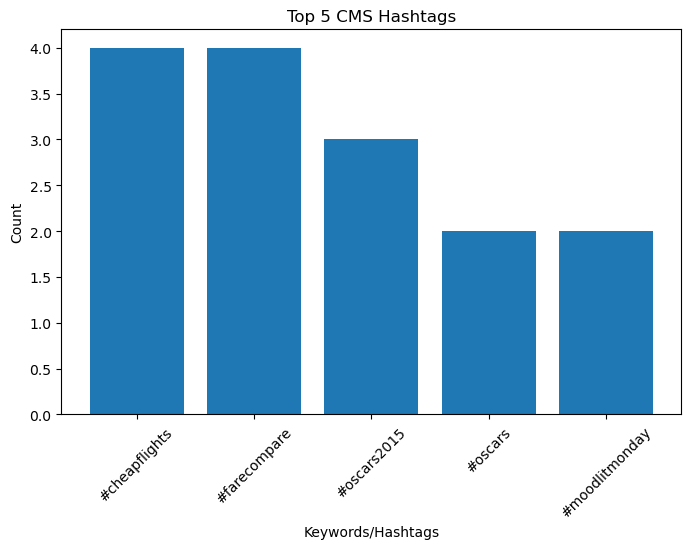

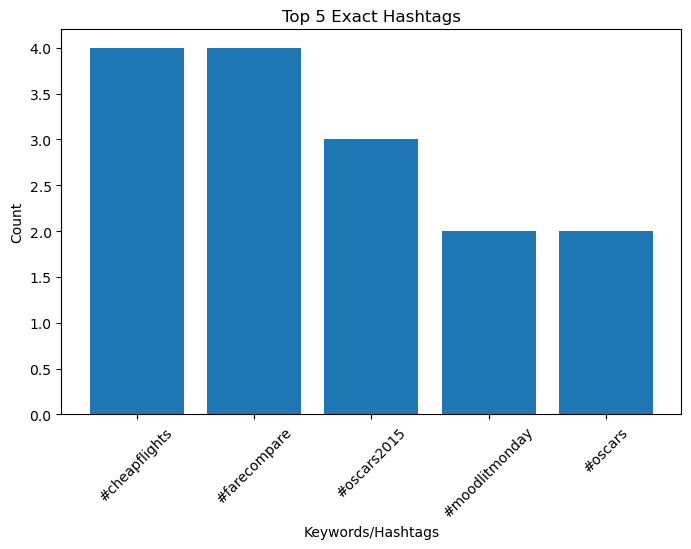


Processed tweets 201 to 400


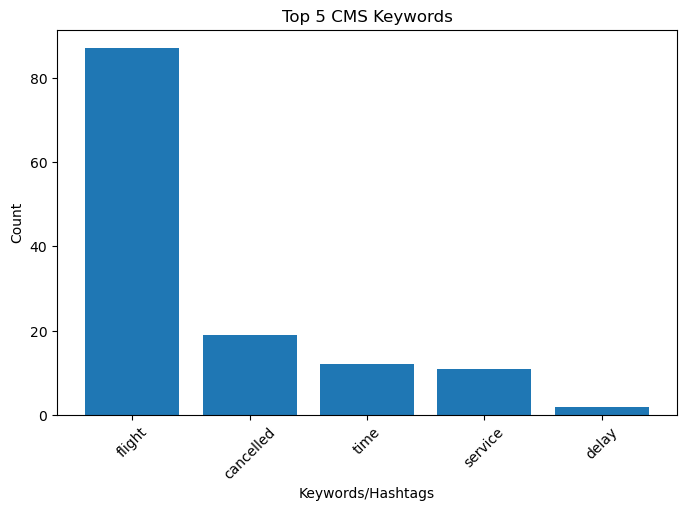

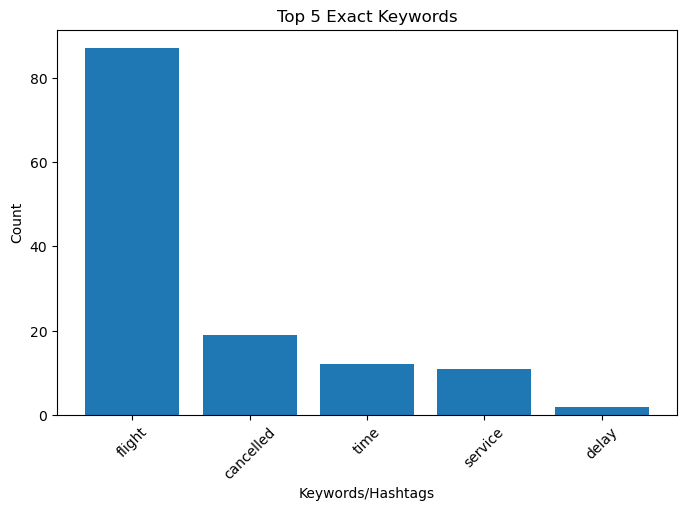

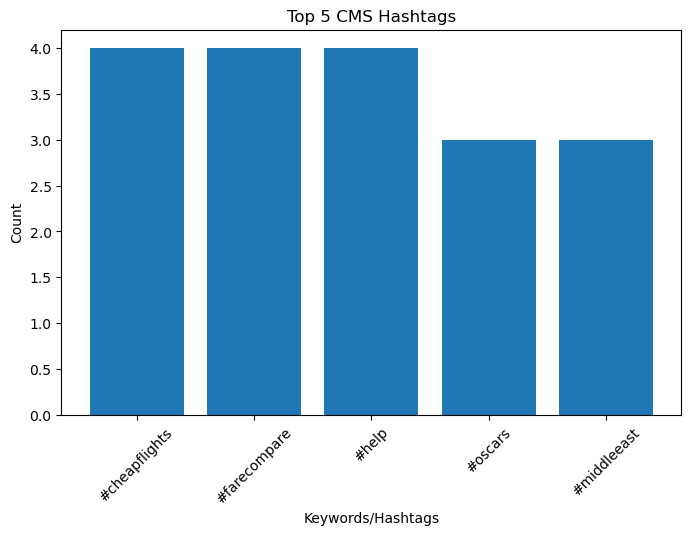

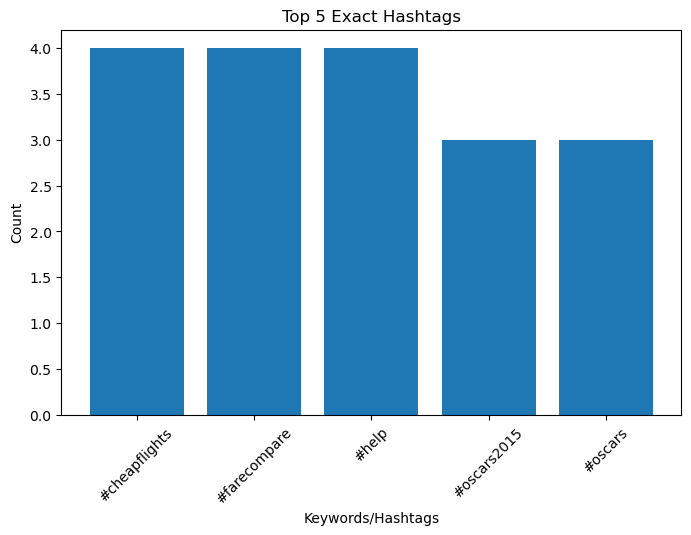


Processed tweets 401 to 600


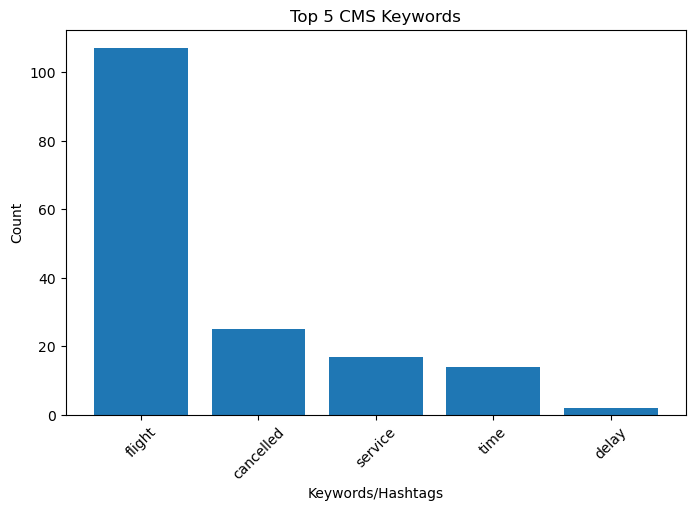

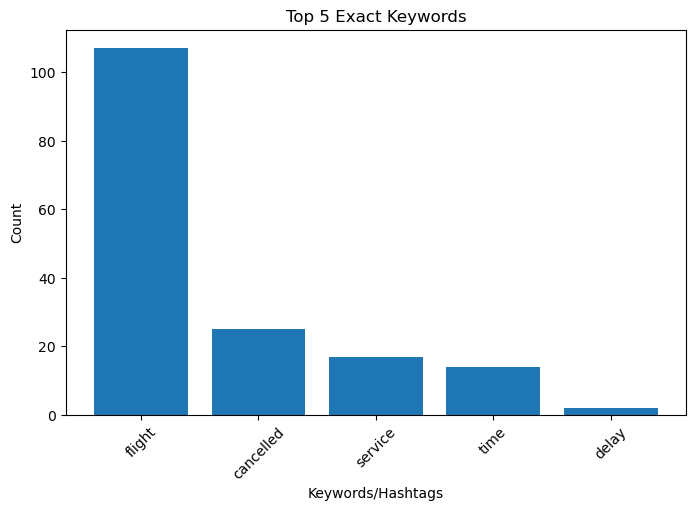

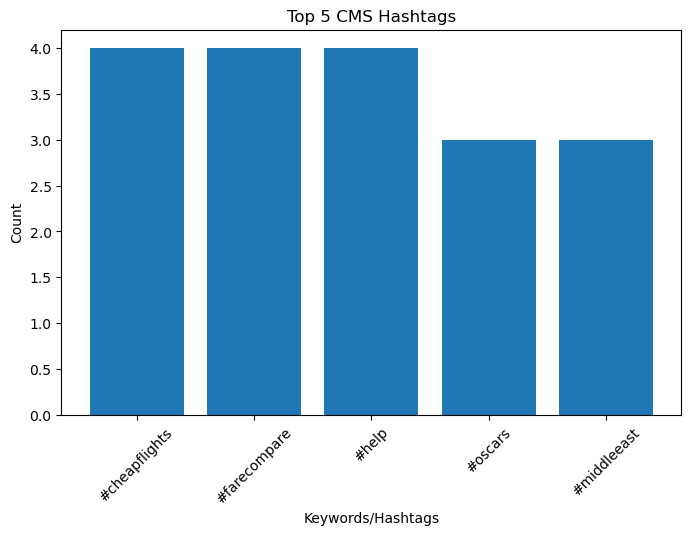

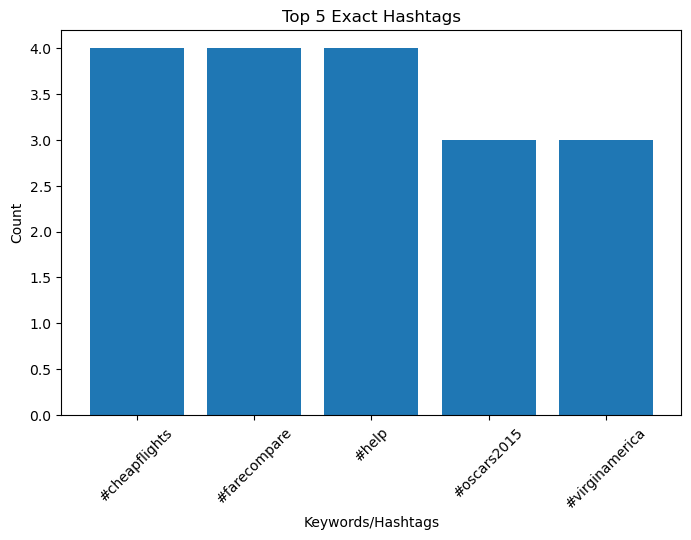


Processed tweets 601 to 800


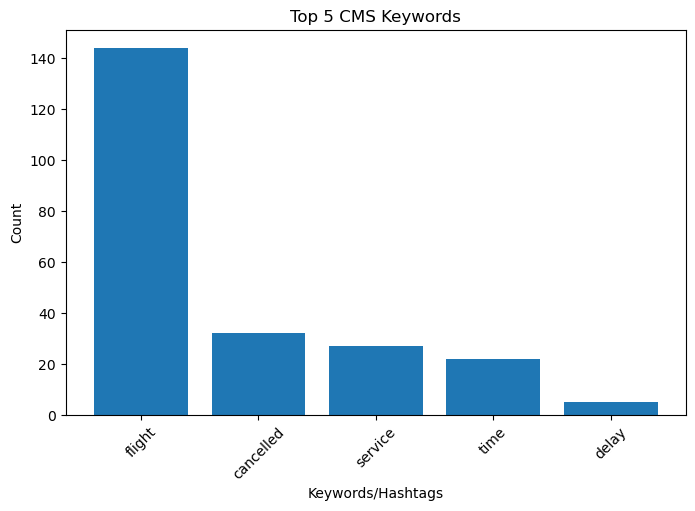

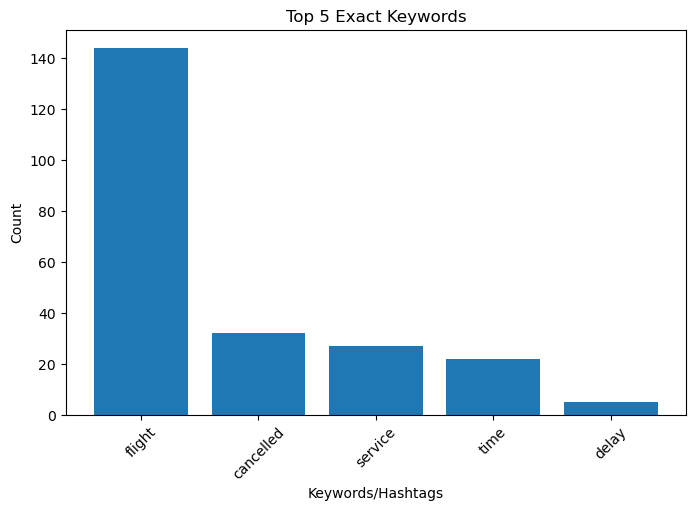

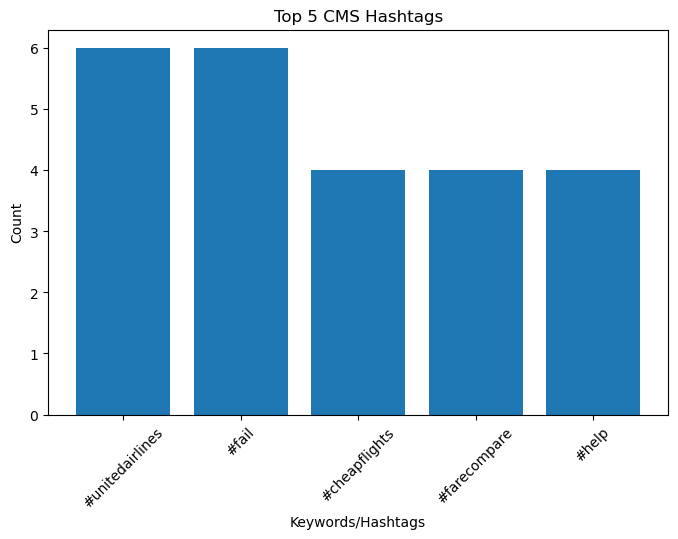

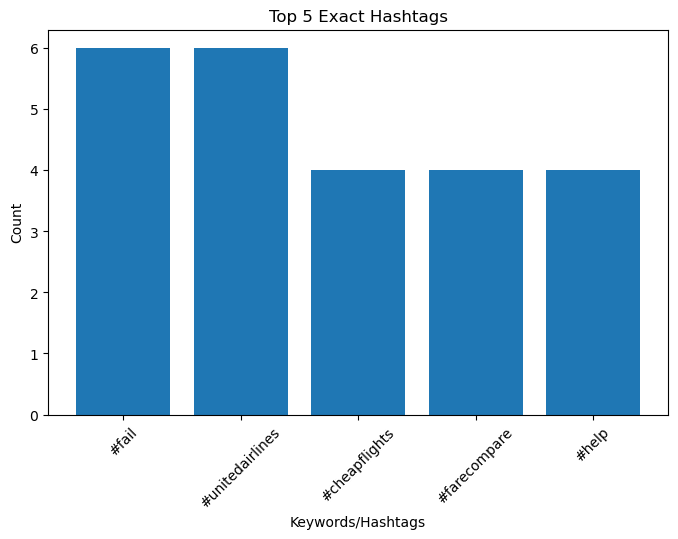


Processed tweets 801 to 1000


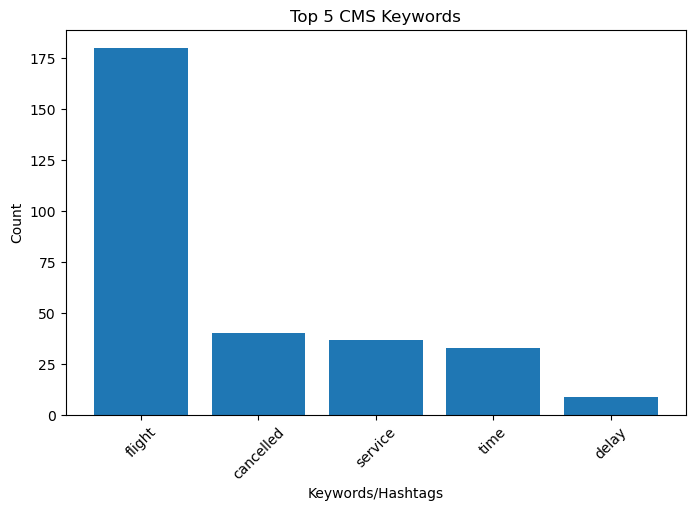

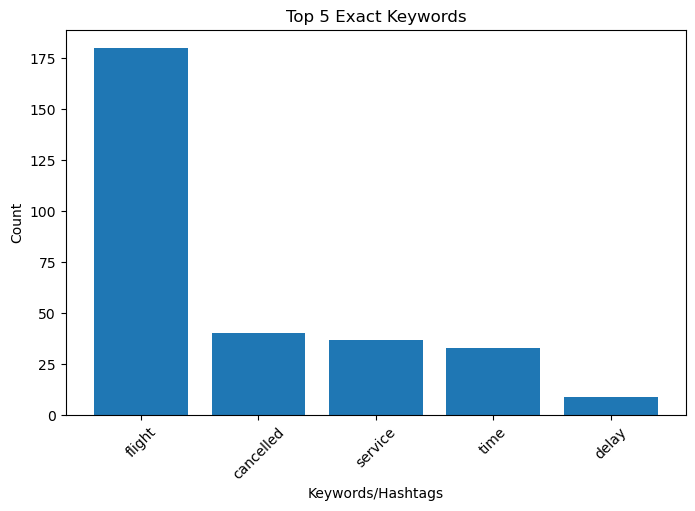

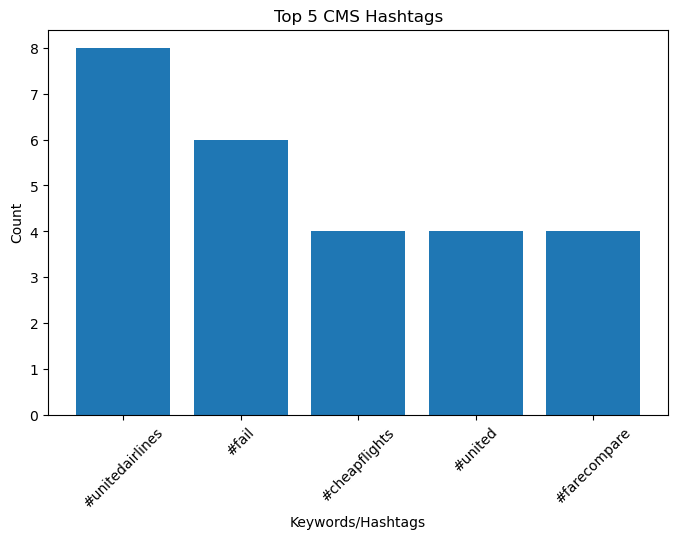

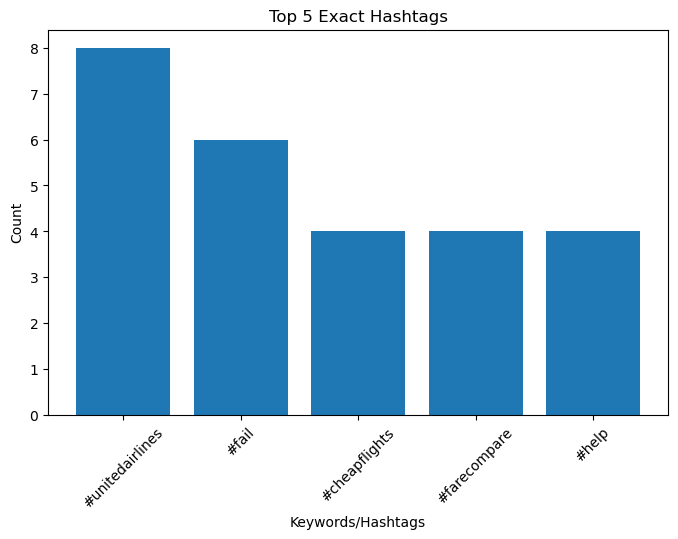


Processed tweets 1001 to 1200


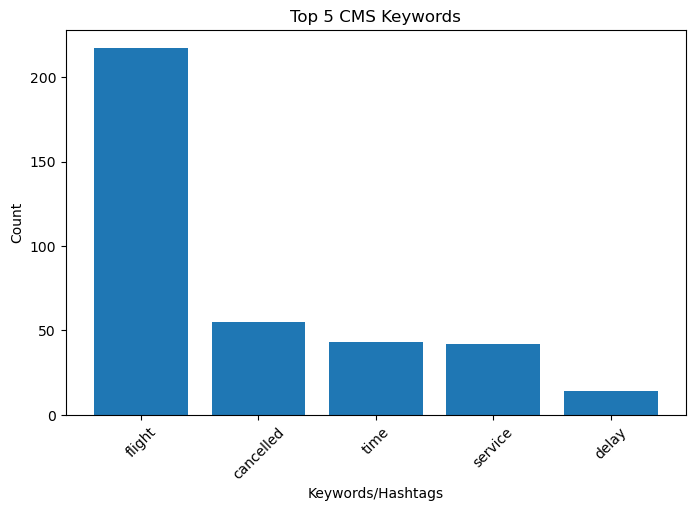

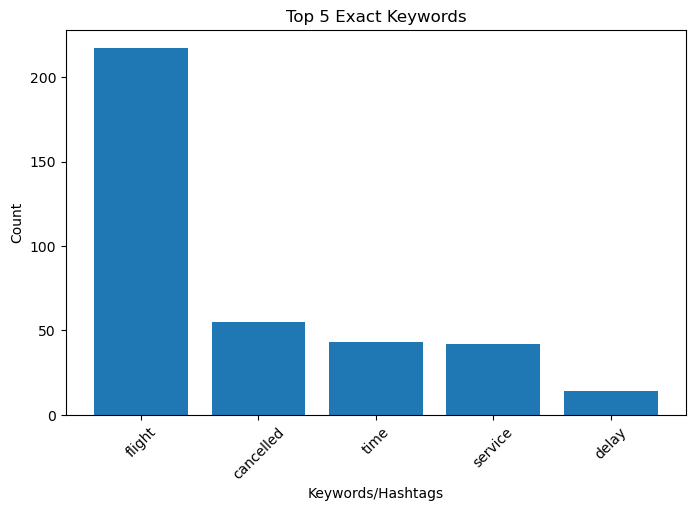

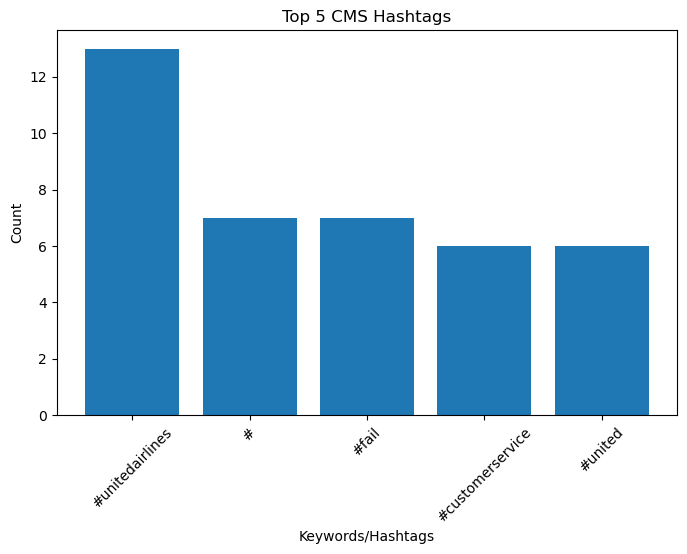

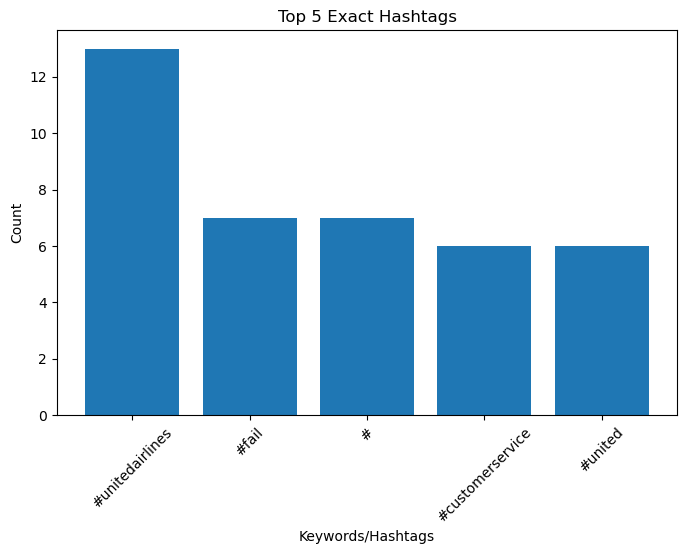


Processed tweets 1201 to 1400


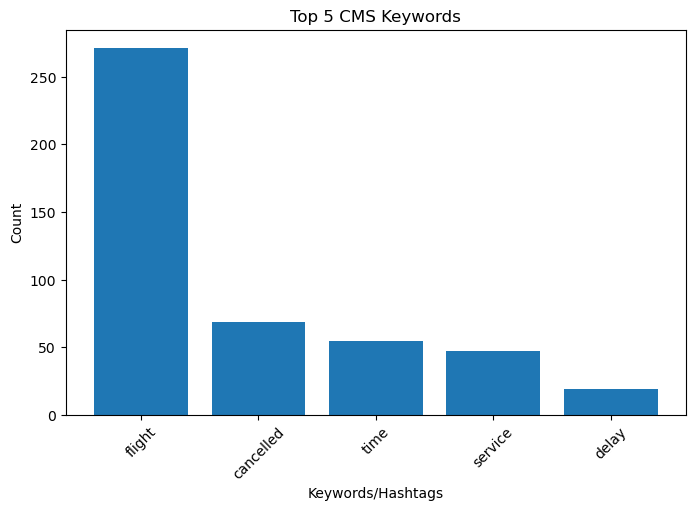

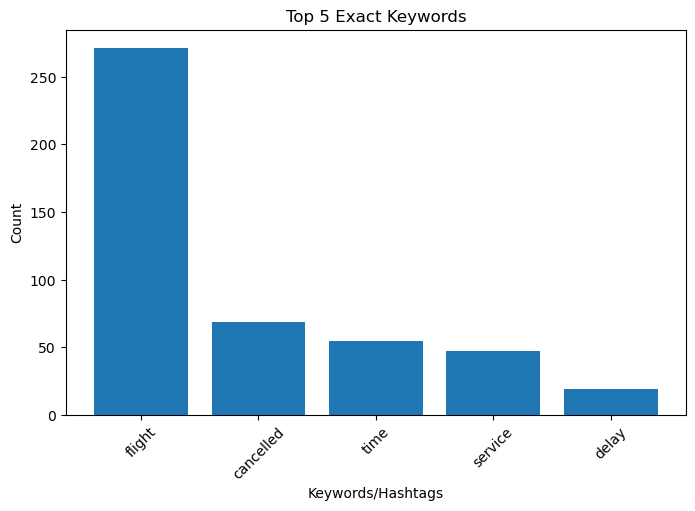

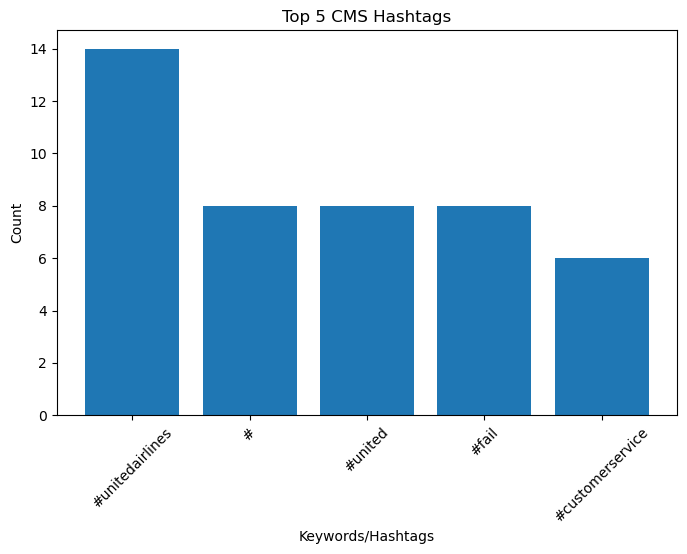

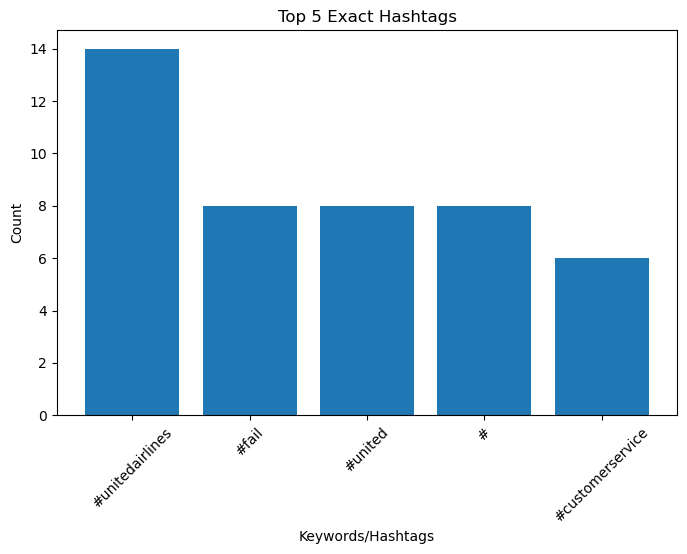


Processed tweets 1401 to 1600


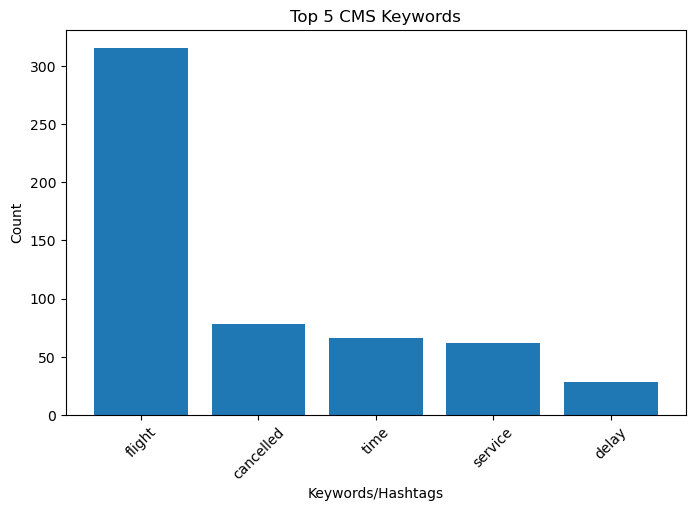

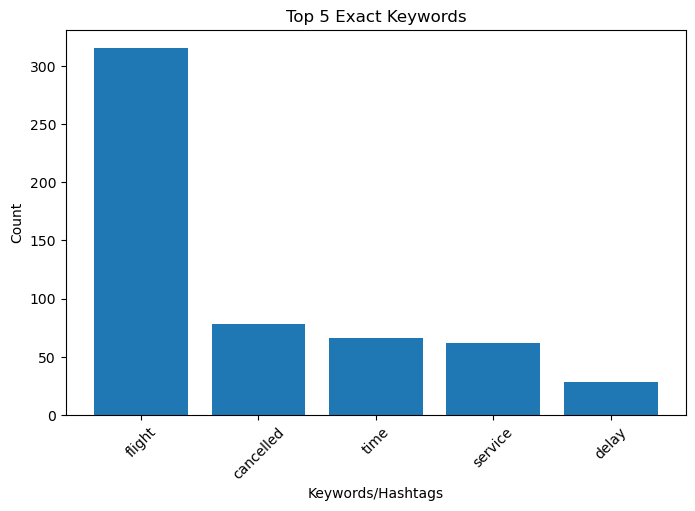

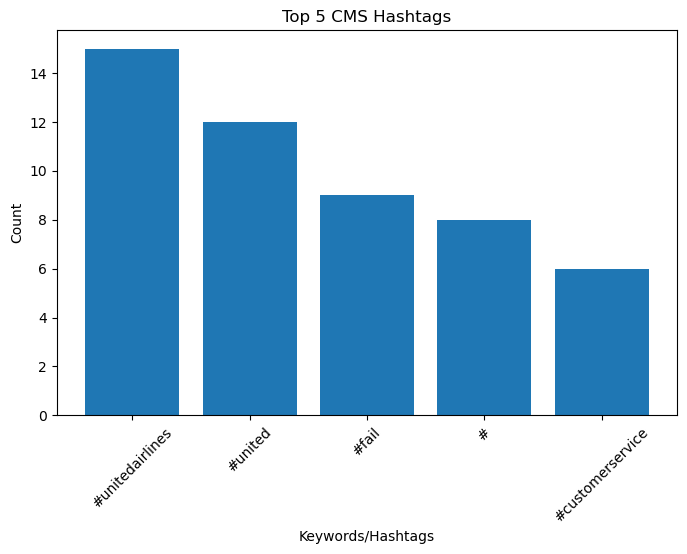

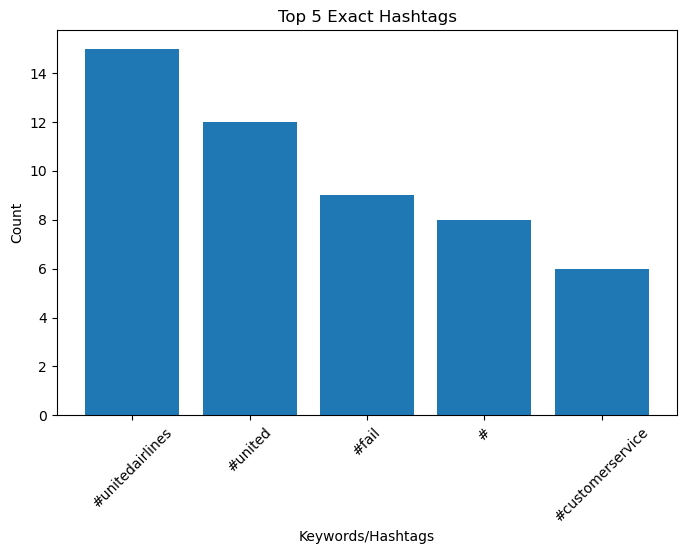


Processed tweets 1601 to 1800


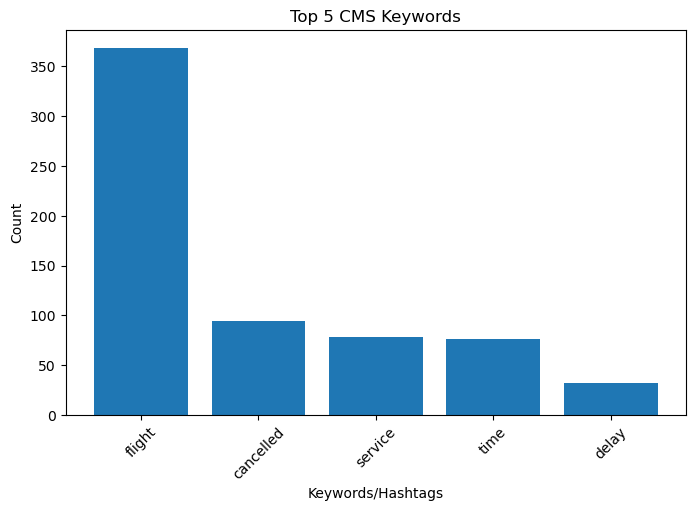

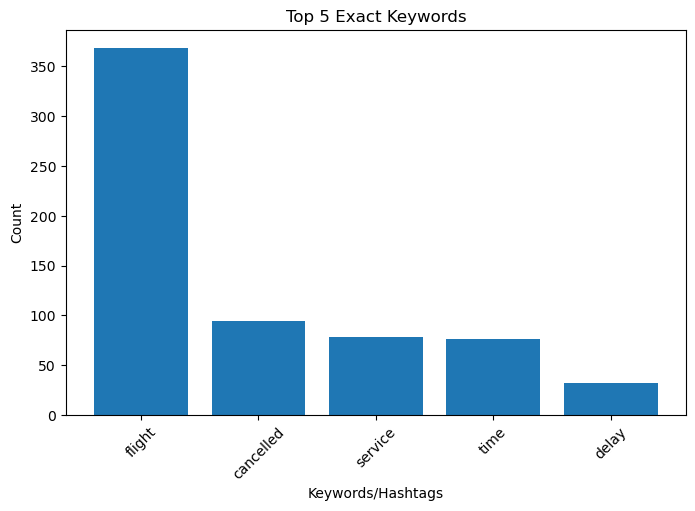

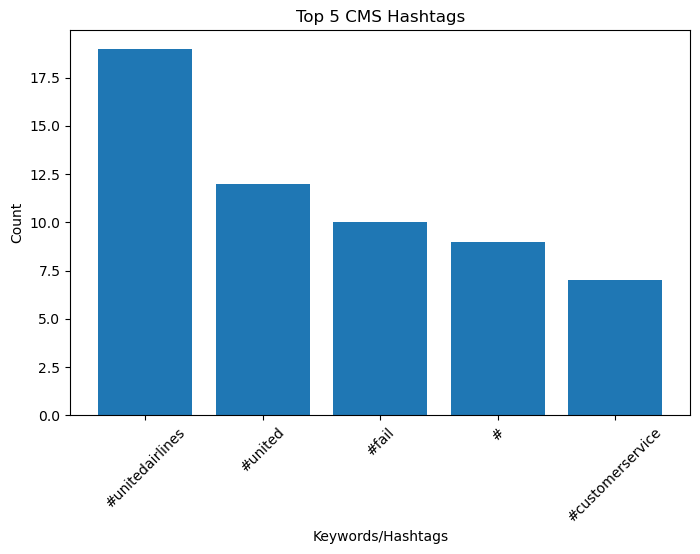

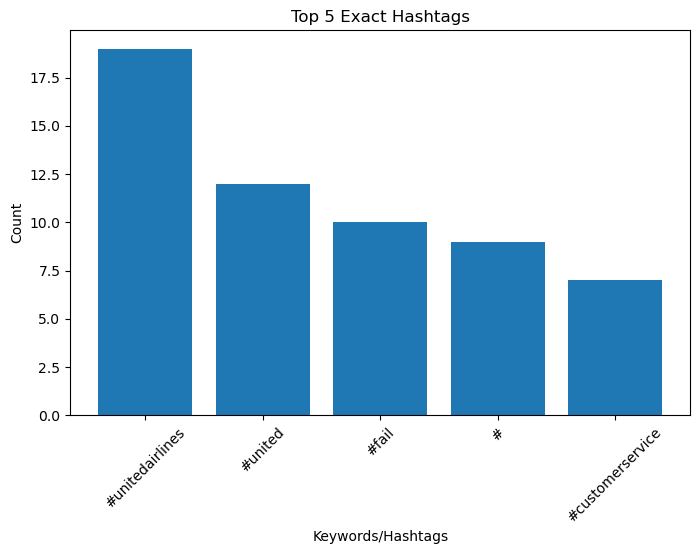


Processed tweets 1801 to 2000


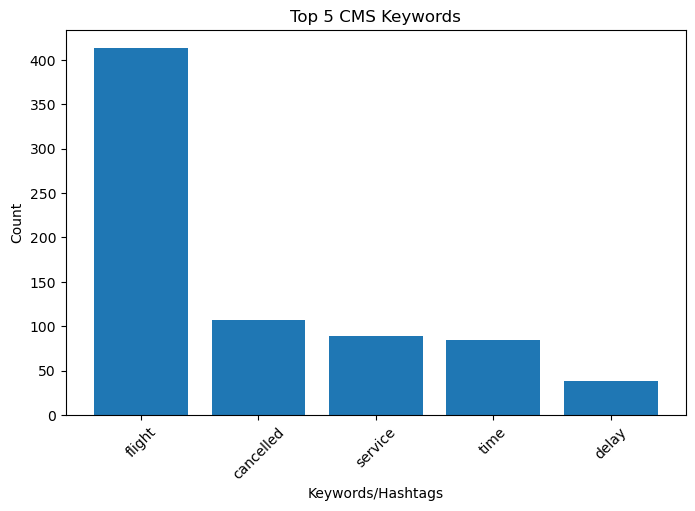

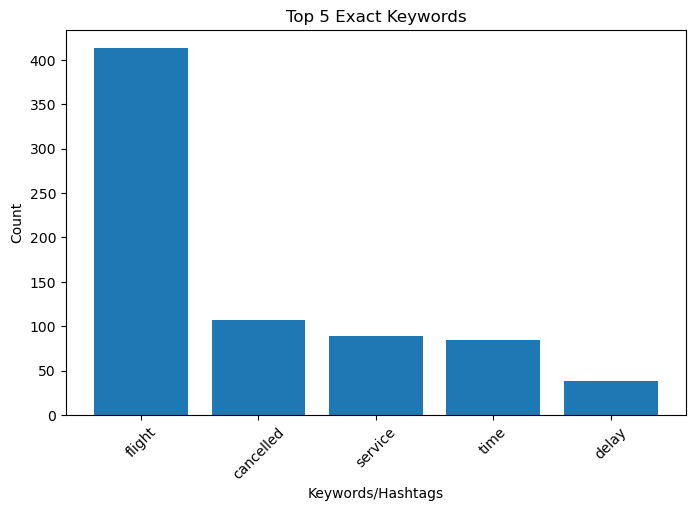

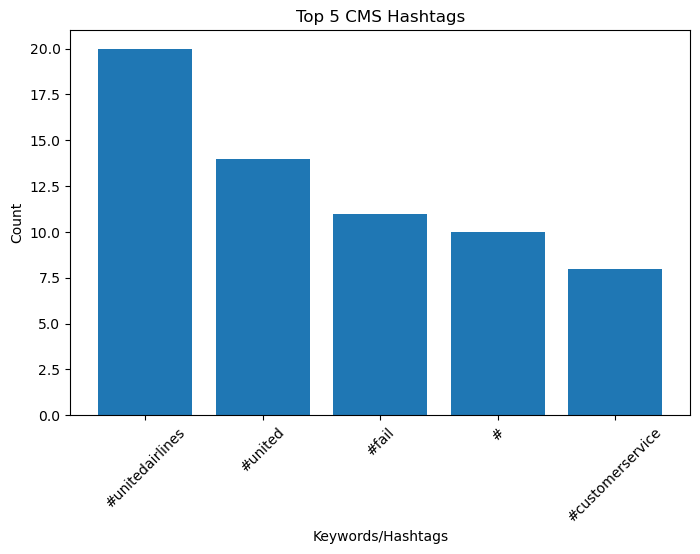

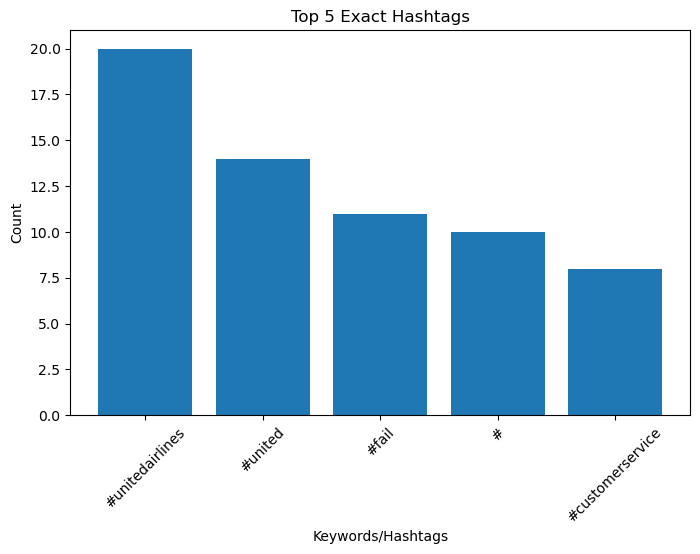

Accuracy Evaluation for Keywords:
delay: CMS Estimate = 38, Exact Count = 38, Error = 0
cancelled: CMS Estimate = 107, Exact Count = 107, Error = 0
time: CMS Estimate = 85, Exact Count = 85, Error = 0
flight: CMS Estimate = 413, Exact Count = 413, Error = 0
price: CMS Estimate = 5, Exact Count = 5, Error = 0
service: CMS Estimate = 89, Exact Count = 89, Error = 0
comfort: CMS Estimate = 1, Exact Count = 1, Error = 0
Total Error for 7 items: 0
Average Error per Item: 0.00

Accuracy Evaluation for Hashtags:
#makestoomuchsense: CMS Estimate = 1, Exact Count = 1, Error = 0
#flierfriendly: CMS Estimate = 2, Exact Count = 2, Error = 0
#bad4business.: CMS Estimate = 1, Exact Count = 1, Error = 0
#friendlyskies?: CMS Estimate = 1, Exact Count = 1, Error = 0
#31daysofoscar: CMS Estimate = 1, Exact Count = 1, Error = 0
#cancelled: CMS Estimate = 1, Exact Count = 1, Error = 0
#usa: CMS Estimate = 2, Exact Count = 2, Error = 0
#cheapflights: CMS Estimate = 4, Exact Count = 4, Error = 0
#amazing!: 

In [37]:
import pandas as pd
import numpy as np
import hashlib
import matplotlib.pyplot as plt
import time
import sys
from collections import defaultdict

# Define Count-Min Sketch class for frequency estimation
class CountMinSketch:
    def __init__(self, width, depth):
        self.width = width
        self.depth = depth
        self.table = np.zeros((depth, width), dtype=int)

    def _hash(self, item, i):
        hash_object = hashlib.md5((str(i) + item).encode())
        return int(hash_object.hexdigest(), 16) % self.width

    def add(self, item):
        for i in range(self.depth):
            index = self._hash(item, i)
            self.table[i, index] += 1

    def estimate(self, item):
        return min(self.table[i, self._hash(item, i)] for i in range(self.depth))

# Initialize Count-Min Sketch for keywords and hashtags
cms_keyword = CountMinSketch(width=1000, depth=5)
cms_hashtag = CountMinSketch(width=1000, depth=5)

# Exact count hash maps for comparative analysis
exact_keyword_count = defaultdict(int)
exact_hashtag_count = defaultdict(int)

# Define keywords of interest and empty set for dynamically collected hashtags
keywords_of_interest = {"flight", "delay", "service", "comfort", "price", "cancelled", "time"}
discovered_hashtags = set()  # Dynamic set for capturing all hashtags

# Function to update CMS and exact counts, and dynamically collect hashtags
def update_counts(tweet_text):
    words = tweet_text.lower().split()
    for word in words:
        if word in keywords_of_interest:
            exact_keyword_count[word] += 1  # Update exact count
        elif word.startswith("#"):
            discovered_hashtags.add(word)  # Collect hashtag for later analysis
            exact_hashtag_count[word] += 1  # Update exact count

# Load the dataset
df = pd.read_csv('twitter-airline-sentiment/Tweets.csv')

# Real-time simulation parameters
batch_size = 200  # Number of tweets to process in each batch
max_tweets = 2000  # Limit on the number of tweets to process
total_tweets = min(len(df), max_tweets)  # Ensure we don't process more than max_tweets

# Performance evaluation data
cms_times = []
exact_times = []
cms_memory = sys.getsizeof(cms_keyword.table)
exact_memory = sys.getsizeof(exact_keyword_count) + sys.getsizeof(exact_hashtag_count)

# Function to plot top estimated counts dynamically for keywords/hashtags
def plot_top_counts(counts, title, top_n=5):
    sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)[:top_n]
    if not sorted_counts:
        print(f"No data available to plot for {title}")
        return
    
    labels, values = zip(*sorted_counts)
    plt.figure(figsize=(8, 5))
    plt.bar(labels, values)
    plt.title(f"Top {top_n} {title}")
    plt.xlabel("Keywords/Hashtags")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

# Simulate real-time data stream processing with performance evaluation
for start in range(0, total_tweets, batch_size):
    end = min(start + batch_size, total_tweets)
    tweet_batch = df['text'][start:end]

    # Measure time for CMS
    start_time = time.time()
    for tweet in tweet_batch:
        words = tweet.lower().split()
        for word in words:
            if word in keywords_of_interest:
                cms_keyword.add(word)
            elif word.startswith("#"):
                cms_hashtag.add(word)
    cms_times.append(time.time() - start_time)

    # Measure time for exact counting
    start_time = time.time()
    for tweet in tweet_batch:
        update_counts(tweet)
    exact_times.append(time.time() - start_time)

    # Print status and plot intermediate results after each batch
    print(f"\nProcessed tweets {start + 1} to {end}")

    # Plot top keyword and hashtag counts for CMS and exact counts
    plot_top_counts({word: cms_keyword.estimate(word) for word in keywords_of_interest}, "CMS Keywords", top_n=5)
    plot_top_counts(exact_keyword_count, "Exact Keywords", top_n=5)
    plot_top_counts({tag: cms_hashtag.estimate(tag) for tag in discovered_hashtags}, "CMS Hashtags", top_n=5)
    plot_top_counts(exact_hashtag_count, "Exact Hashtags", top_n=5)

# Accuracy evaluation: compare CMS estimates with exact counts
def evaluate_accuracy(cms, exact_counts, items):
    total_error = 0
    for item in items:
        cms_count = cms.estimate(item)
        exact_count = exact_counts[item]
        error = abs(cms_count - exact_count)
        total_error += error
        print(f"{item}: CMS Estimate = {cms_count}, Exact Count = {exact_count}, Error = {error}")
    print(f"Total Error for {len(items)} items: {total_error}")
    print(f"Average Error per Item: {total_error / len(items):.2f}\n")

# Evaluate accuracy of CMS compared to exact counts for keywords and hashtags
print("Accuracy Evaluation for Keywords:")
evaluate_accuracy(cms_keyword, exact_keyword_count, keywords_of_interest)

print("Accuracy Evaluation for Hashtags:")
evaluate_accuracy(cms_hashtag, exact_hashtag_count, discovered_hashtags)

# Display performance summary
print("\nPerformance Summary:")
print(f"CMS Average Processing Time per Batch: {sum(cms_times) / len(cms_times):.4f} seconds")
print(f"Exact Counting Average Processing Time per Batch: {sum(exact_times) / len(exact_times):.4f} seconds")
print(f"CMS Memory Usage: {cms_memory} bytes")
print(f"Exact Counting Memory Usage: {exact_memory} bytes")


Batch Size: 50
  CMS Average Time per Item: 0.000000 seconds
  Exact Counting Average Time per Item: 0.000020 seconds

Batch Size: 100
  CMS Average Time per Item: 0.000017 seconds
  Exact Counting Average Time per Item: 0.000010 seconds

Batch Size: 200
  CMS Average Time per Item: 0.000010 seconds
  Exact Counting Average Time per Item: 0.000005 seconds

Batch Size: 400
  CMS Average Time per Item: 0.000012 seconds
  Exact Counting Average Time per Item: 0.000006 seconds

Batch Size: 800
  CMS Average Time per Item: 0.000014 seconds
  Exact Counting Average Time per Item: 0.000004 seconds



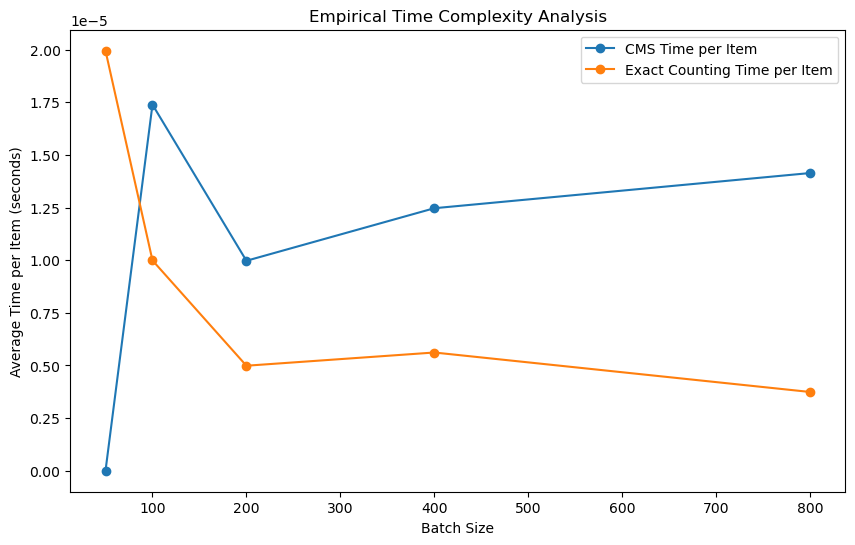

In [39]:
import random

# Define different batch sizes for empirical time complexity analysis
batch_sizes = [50, 100, 200, 400, 800]
time_per_item_cms = []
time_per_item_exact = []

# Function to run time complexity analysis for different batch sizes
def analyze_time_complexity(batch_sizes, df, keywords_of_interest):
    for batch_size in batch_sizes:
        # Randomly sample tweets to simulate different batch sizes
        sample_tweets = random.sample(list(df['text']), batch_size)

        # Time CMS processing
        start_time = time.time()
        for tweet in sample_tweets:
            words = tweet.lower().split()
            for word in words:
                if word in keywords_of_interest:
                    cms_keyword.add(word)
                elif word.startswith("#"):
                    cms_hashtag.add(word)
        cms_time = time.time() - start_time
        avg_time_cms = cms_time / batch_size
        time_per_item_cms.append(avg_time_cms)

        # Time exact counting processing
        start_time = time.time()
        for tweet in sample_tweets:
            update_counts(tweet)  # Call exact counting function
        exact_time = time.time() - start_time
        avg_time_exact = exact_time / batch_size
        time_per_item_exact.append(avg_time_exact)

        # Print results for the current batch size
        print(f"Batch Size: {batch_size}")
        print(f"  CMS Average Time per Item: {avg_time_cms:.6f} seconds")
        print(f"  Exact Counting Average Time per Item: {avg_time_exact:.6f} seconds\n")

# Run time complexity analysis
analyze_time_complexity(batch_sizes, df, keywords_of_interest)

# Plotting time complexity results
plt.figure(figsize=(10, 6))
plt.plot(batch_sizes, time_per_item_cms, label="CMS Time per Item", marker="o")
plt.plot(batch_sizes, time_per_item_exact, label="Exact Counting Time per Item", marker="o")
plt.xlabel("Batch Size")
plt.ylabel("Average Time per Item (seconds)")
plt.title("Empirical Time Complexity Analysis")
plt.legend()
plt.show()
